<a href="https://colab.research.google.com/github/nirmaljb/deep-learning-notebooks/blob/main/Object_detection_yolo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
!pip install ultralytics

In [9]:
from ultralytics import YOLO

In [10]:
model = YOLO("yolov8m.pt")

In [11]:
print("Model architecture: \n\n", model, "\n\n")
print("type(model): \t", type(model), "\n")

Model architecture: 

 YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(48, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(48, 96, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(96, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(96, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(96, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(192, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(96, eps=0.001, momentum=0.03, affi

In [12]:
import numpy as np
import cv2      #OpenCV for basic image processing tasks
import matplotlib.pyplot as plt

# Import Pytorch as most of the data items will be in the form of Pytorch Tensors

import torch

test_image.shape: 	 (176, 286, 3) 

Sample test image: 



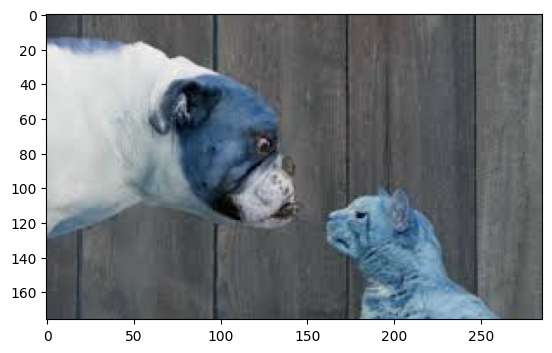

In [13]:
test_image_path = '/content/drive/MyDrive/Dataset_cat_dog/Test/Image4.jpg'
test_image = cv2.imread(test_image_path)

print("test_image.shape: \t", test_image.shape, "\n")

# Display the image read

print("Sample test image: \n")
plt.imshow(test_image)

In [14]:
results = model.predict(test_image)
print("\ntype(results): \t", type(results), "\n\n")


0: 416x640 1 cat, 1 dog, 204.6ms
Speed: 18.2ms preprocess, 204.6ms inference, 51.6ms postprocess per image at shape (1, 3, 416, 640)

type(results): 	 <class 'list'> 




In [15]:
print("Object Detection Results: \n", results, "\n")
print("len(results): \t", len(results), "\n")

Object Detection Results: 
 [ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57:

In [16]:
result = results[0]
print("result: \n", result, "\n")

result: 
 ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'pott

In [17]:
class_names = result.names
print("type(class_names): \t", type(class_names), "\n")
print("The model can detect ", len(class_names), " different object categories \n")

# let's get all the object categorires and their class IDs neatly

print("Class ID: \t Object Class Name \n")
for key in class_names.keys():
    print(key, "\t\t", class_names[key])

type(class_names): 	 <class 'dict'> 

The model can detect  80  different object categories 

Class ID: 	 Object Class Name 

0 		 person
1 		 bicycle
2 		 car
3 		 motorcycle
4 		 airplane
5 		 bus
6 		 train
7 		 truck
8 		 boat
9 		 traffic light
10 		 fire hydrant
11 		 stop sign
12 		 parking meter
13 		 bench
14 		 bird
15 		 cat
16 		 dog
17 		 horse
18 		 sheep
19 		 cow
20 		 elephant
21 		 bear
22 		 zebra
23 		 giraffe
24 		 backpack
25 		 umbrella
26 		 handbag
27 		 tie
28 		 suitcase
29 		 frisbee
30 		 skis
31 		 snowboard
32 		 sports ball
33 		 kite
34 		 baseball bat
35 		 baseball glove
36 		 skateboard
37 		 surfboard
38 		 tennis racket
39 		 bottle
40 		 wine glass
41 		 cup
42 		 fork
43 		 knife
44 		 spoon
45 		 bowl
46 		 banana
47 		 apple
48 		 sandwich
49 		 orange
50 		 broccoli
51 		 carrot
52 		 hot dog
53 		 pizza
54 		 donut
55 		 cake
56 		 chair
57 		 couch
58 		 potted plant
59 		 bed
60 		 dining table
61 		 toilet
62 		 tv
63 		 laptop
64 		 mouse

original_test_image.shape: 	 (176, 286, 3) 



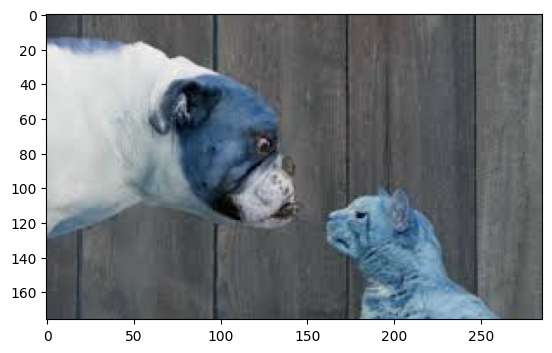

In [18]:
original_test_image = result.orig_img
print("original_test_image.shape: \t", original_test_image.shape, "\n")

original_test_image_copy = original_test_image

plt.imshow(original_test_image)

In [19]:
computation_time = result.speed
print("type(computation_time): \t", type(computation_time), "\n\n")

# Let's get the computation information neatly
print("Task \t\t Time Taken \n")
for key in computation_time.keys():
    print(key, "\t", computation_time[key])

type(computation_time): 	 <class 'dict'> 


Task 		 Time Taken 

preprocess 	 18.223268000156168
inference 	 204.59374399979424
postprocess 	 51.579318999984025


In [20]:
bounding_box_predictions = result.boxes
print("type(bounding_box_predictions) \t", type(bounding_box_predictions), "\n\n")
print("bounding_box_predictions: \n", bounding_box_predictions, "\n")

type(bounding_box_predictions) 	 <class 'ultralytics.engine.results.Boxes'> 


bounding_box_predictions: 
 ultralytics.engine.results.Boxes object with attributes:

cls: tensor([16., 15.], device='cuda:0')
conf: tensor([0.8415, 0.5631], device='cuda:0')
data: tensor([[  0.3714,  13.9707, 144.3292, 129.1494,   0.8415,  16.0000],
        [160.3088,  97.8415, 262.2212, 174.7045,   0.5631,  15.0000]], device='cuda:0')
id: None
is_track: False
orig_shape: (176, 286)
shape: torch.Size([2, 6])
xywh: tensor([[ 72.3503,  71.5600, 143.9578, 115.1787],
        [211.2650, 136.2730, 101.9124,  76.8630]], device='cuda:0')
xywhn: tensor([[0.2530, 0.4066, 0.5033, 0.6544],
        [0.7387, 0.7743, 0.3563, 0.4367]], device='cuda:0')
xyxy: tensor([[  0.3714,  13.9707, 144.3292, 129.1494],
        [160.3088,  97.8415, 262.2212, 174.7045]], device='cuda:0')
xyxyn: tensor([[0.0013, 0.0794, 0.5046, 0.7338],
        [0.5605, 0.5559, 0.9169, 0.9926]], device='cuda:0') 



In [21]:
torch.set_printoptions(precision=2, sci_mode=None)
np.set_printoptions(precision=2, suppress=None)

type(bounding_box_xyxy_coordinates):  <class 'torch.Tensor'> 

Number of bounding boxes detected: 	 2 

Showing box:  1 



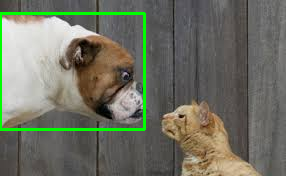




Showing box:  2 



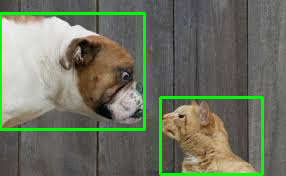

In [22]:
# Let's analyze the bounding box returned by the model
# Let's draw a bounding box around the image
from google.colab.patches import cv2_imshow

bounding_box_xyxy_coordinates = bounding_box_predictions.xyxy
print("type(bounding_box_xyxy_coordinates): ", type(bounding_box_xyxy_coordinates),"\n")

bounding_box_xyxy_coordinates_list = bounding_box_xyxy_coordinates.tolist()
print("Number of bounding boxes detected: \t", len(bounding_box_xyxy_coordinates_list), "\n")

for box_index in range(len(bounding_box_xyxy_coordinates_list)):
    print("Showing box: ", box_index+1, "\n")
    x1, y1, x2, y2 = bounding_box_xyxy_coordinates_list[box_index]
    x1 = int(x1)
    x2 = int(x2)
    y1 = int(y1)
    y2 = int(y2)
    cv2.rectangle(original_test_image, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2_imshow(original_test_image)
    print("\n\n")

## Training Yolo

In [ ]:
model.train(data="/content/drive/MyDrive/road_signs/data2.yaml", epochs=1)

Ultralytics 8.4.31 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/road_signs/data2.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10